In [1]:
import sys
sys.path.append("../")

import os
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"

%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import numpy as np
import arviz as az
import mpltern
import corner
import pickle
import logging
from tqdm import tqdm

In [3]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rc_file('../notebooks/matplotlibrc')
import mpltern

In [4]:
jax.devices()

[StreamExecutorGpuDevice(id=0, process_index=0, slice_index=0),
 StreamExecutorGpuDevice(id=1, process_index=0, slice_index=0)]

In [5]:
DATA_DIR = '../data/posteriors/compare_samplers'

In [6]:
from models.np_model import NPModel

In [7]:
default_expand_keys = {
    'theta_bulge_poiss' : ['theta_p_mcdermott2022', 'theta_p_mcdermott2022_bbp', 'theta_p_mcdermott2022_x',
                           'theta_p_macias2019', 'theta_p_coleman2019'],
    'theta_bulge_ps' : ['theta_ps_mcdermott2022', 'theta_ps_mcdermott2022_bbp', 'theta_ps_mcdermott2022_x',
                        'theta_ps_macias2019', 'theta_ps_coleman2019'],
    'theta_ics'    : ['theta_MO_ics', 'theta_MA_ics', 'theta_MF_ics'],
    'theta_pibrem' : ['theta_MO_pib', 'theta_MA_pib', 'theta_MF_pib'],
}

default_exclude_keys = ['auto_shared_latent']
#default_exclude_keys = []

def expand_samples(samples, expand_keys=default_expand_keys, exclude_keys=default_exclude_keys, conversion_func=(lambda x: x)):
    
    samples_new = {}
    for k in samples.keys():
        if k in exclude_keys:
            continue
        if k in expand_keys:
            for i in range(samples[k].shape[-1]):
                samples_new[expand_keys[k][i]] = conversion_func(samples[k][...,i])
        else:
            samples_new[k] = conversion_func(samples[k])
            
    return samples_new

## 1. Poisson

In [39]:
pmodel = NPModel(
    non_poissonian=False,
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=256,
)

### 1.1 SVI

#### 1.1.1 RNG

In [40]:
svi_results_arr = []

for i, prngk in enumerate([123, 234, 345]):
    svi_results = pmodel.fit_svi(
        rng_key=jax.random.PRNGKey(prngk),
        n_steps=7500,
        guide="iaf_mixture",
        num_base_mixture=10,
        lr=5e-5,
        num_flows=5,
        hidden_dims=[256, 256],
        num_particles=8,
    )
    svi_results_arr.append(svi_results)
    samples = pmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(prngk), num_samples=50000)
    pickle.dump(expand_samples(samples), open(f'{DATA_DIR}/rng/{i}.p', 'wb'))

100%|████████████████████| 7500/7500 [03:40<00:00, 34.01it/s, init loss: 634852.0364, avg. loss [7126-7500]: 58523.4765]


In [ ]:
for sr in svi_results_arr:
    plt.plot(np.arange(len(sr.losses))[1000:], sr.losses[1000:], alpha=0.3)
plt.ylim(58320, 58350)
plt.xlabel('steps')
plt.ylabel('Trace_ELBO loss')

In [ ]:
for sr in svi_results_arr:
    plt.plot(sr.losses[3000:])

#### 1.1.2 SVI: iaf vs iaf_mixture

In [28]:
svi_results = pmodel.fit_svi(rng_key=jax.random.PRNGKey(35),
                             n_steps=15000,
                             guide="iaf_mixture",
                             num_base_mixture=1,
                             lr=1e-5)

100%|███████████████| 15000/15000 [02:13<00:00, 112.52it/s, init loss: 192106.3079, avg. loss [14251-15000]: 58329.0449]


In [29]:
samples = pmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(345), num_samples=50000)
pickle.dump(expand_samples(samples), open(f'{DATA_DIR}/svi_iafmixture_C1_samples.p', 'wb'))

In [38]:
svi_results = pmodel.fit_svi(rng_key=jax.random.PRNGKey(9877),
                             n_steps=15000,
                             guide="iaf",
                             lr=2e-4)

100%|███████████████| 15000/15000 [02:13<00:00, 112.78it/s, init loss: 195385.9736, avg. loss [14251-15000]: 58341.6099]


In [33]:
samples = pmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(765), num_samples=50000)
pickle.dump(expand_samples(samples), open(f'{DATA_DIR}/svi_iaf2_samples.p', 'wb'))

### 1.2 NUTS

In [20]:
pmodel.run_nuts(num_samples=10000)

sample: 100%|█████████████████████████████████████████████████████████████████████| 10500/10500 [43:20<00:00,  4.04it/s]


In [21]:
pickle.dump(expand_samples(pmodel.mcmc.get_samples()), open(f'{DATA_DIR}/nuts_samples.p', 'wb'))

### 1.3 Parallel tempering

In [22]:
pmodel.run_parallel_tempering_hmc(num_samples=50000)

sample: 100%|█████████████████████████████████████████████████████████████████████| 50600/50600 [52:21<00:00, 16.11it/s]


In [23]:
pickle.dump(expand_samples(pmodel.mcmc.get_samples()), open(f'{DATA_DIR}/pthmc_samples.p', 'wb'))

### 1.4 JAXNS

In [ ]:
from numpyro.contrib.nested_sampling import NestedSampler

In [ ]:
import logging
logger = logging.getLogger('jaxns')
logger.setLevel(logging.INFO)

In [ ]:
ns = NestedSampler(pmodel.model)

In [ ]:
ns.run(jax.random.PRNGKey(42), pmodel.data)

In [ ]:
ns.print_summary()

## 2. NP

In [8]:
npmodel = NPModel(
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
)

Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


### 2.1 SVI (multiple)

In [9]:
svi_results = npmodel.fit_svi(
    rng_key=jax.random.PRNGKey(4234),
    n_steps=50,
    guide="iaf",
    lr=5e-5,
    num_base_mixture=5,
    num_particles=8,
)

100%|█████████████████████████████| 50/50 [01:19<00:00,  1.58s/it, init loss: 25311.9507, avg. loss [49-50]: 24296.1251]


In [10]:
samples = npmodel.get_posterior_samples(
    rng_key=jax.random.PRNGKey(42342),
    num_samples=50000,
)

In [11]:
pickle.dump(expand_samples(samples), open(f'../data/posteriors/unfinished_samples.p', 'wb'))

### view

In [37]:
samples.keys()

dict_keys(['np_sviiaf', 'np_sviiafm_nbm5', 'np_sviiafm_par8', 'np_sviiaf_par8'])

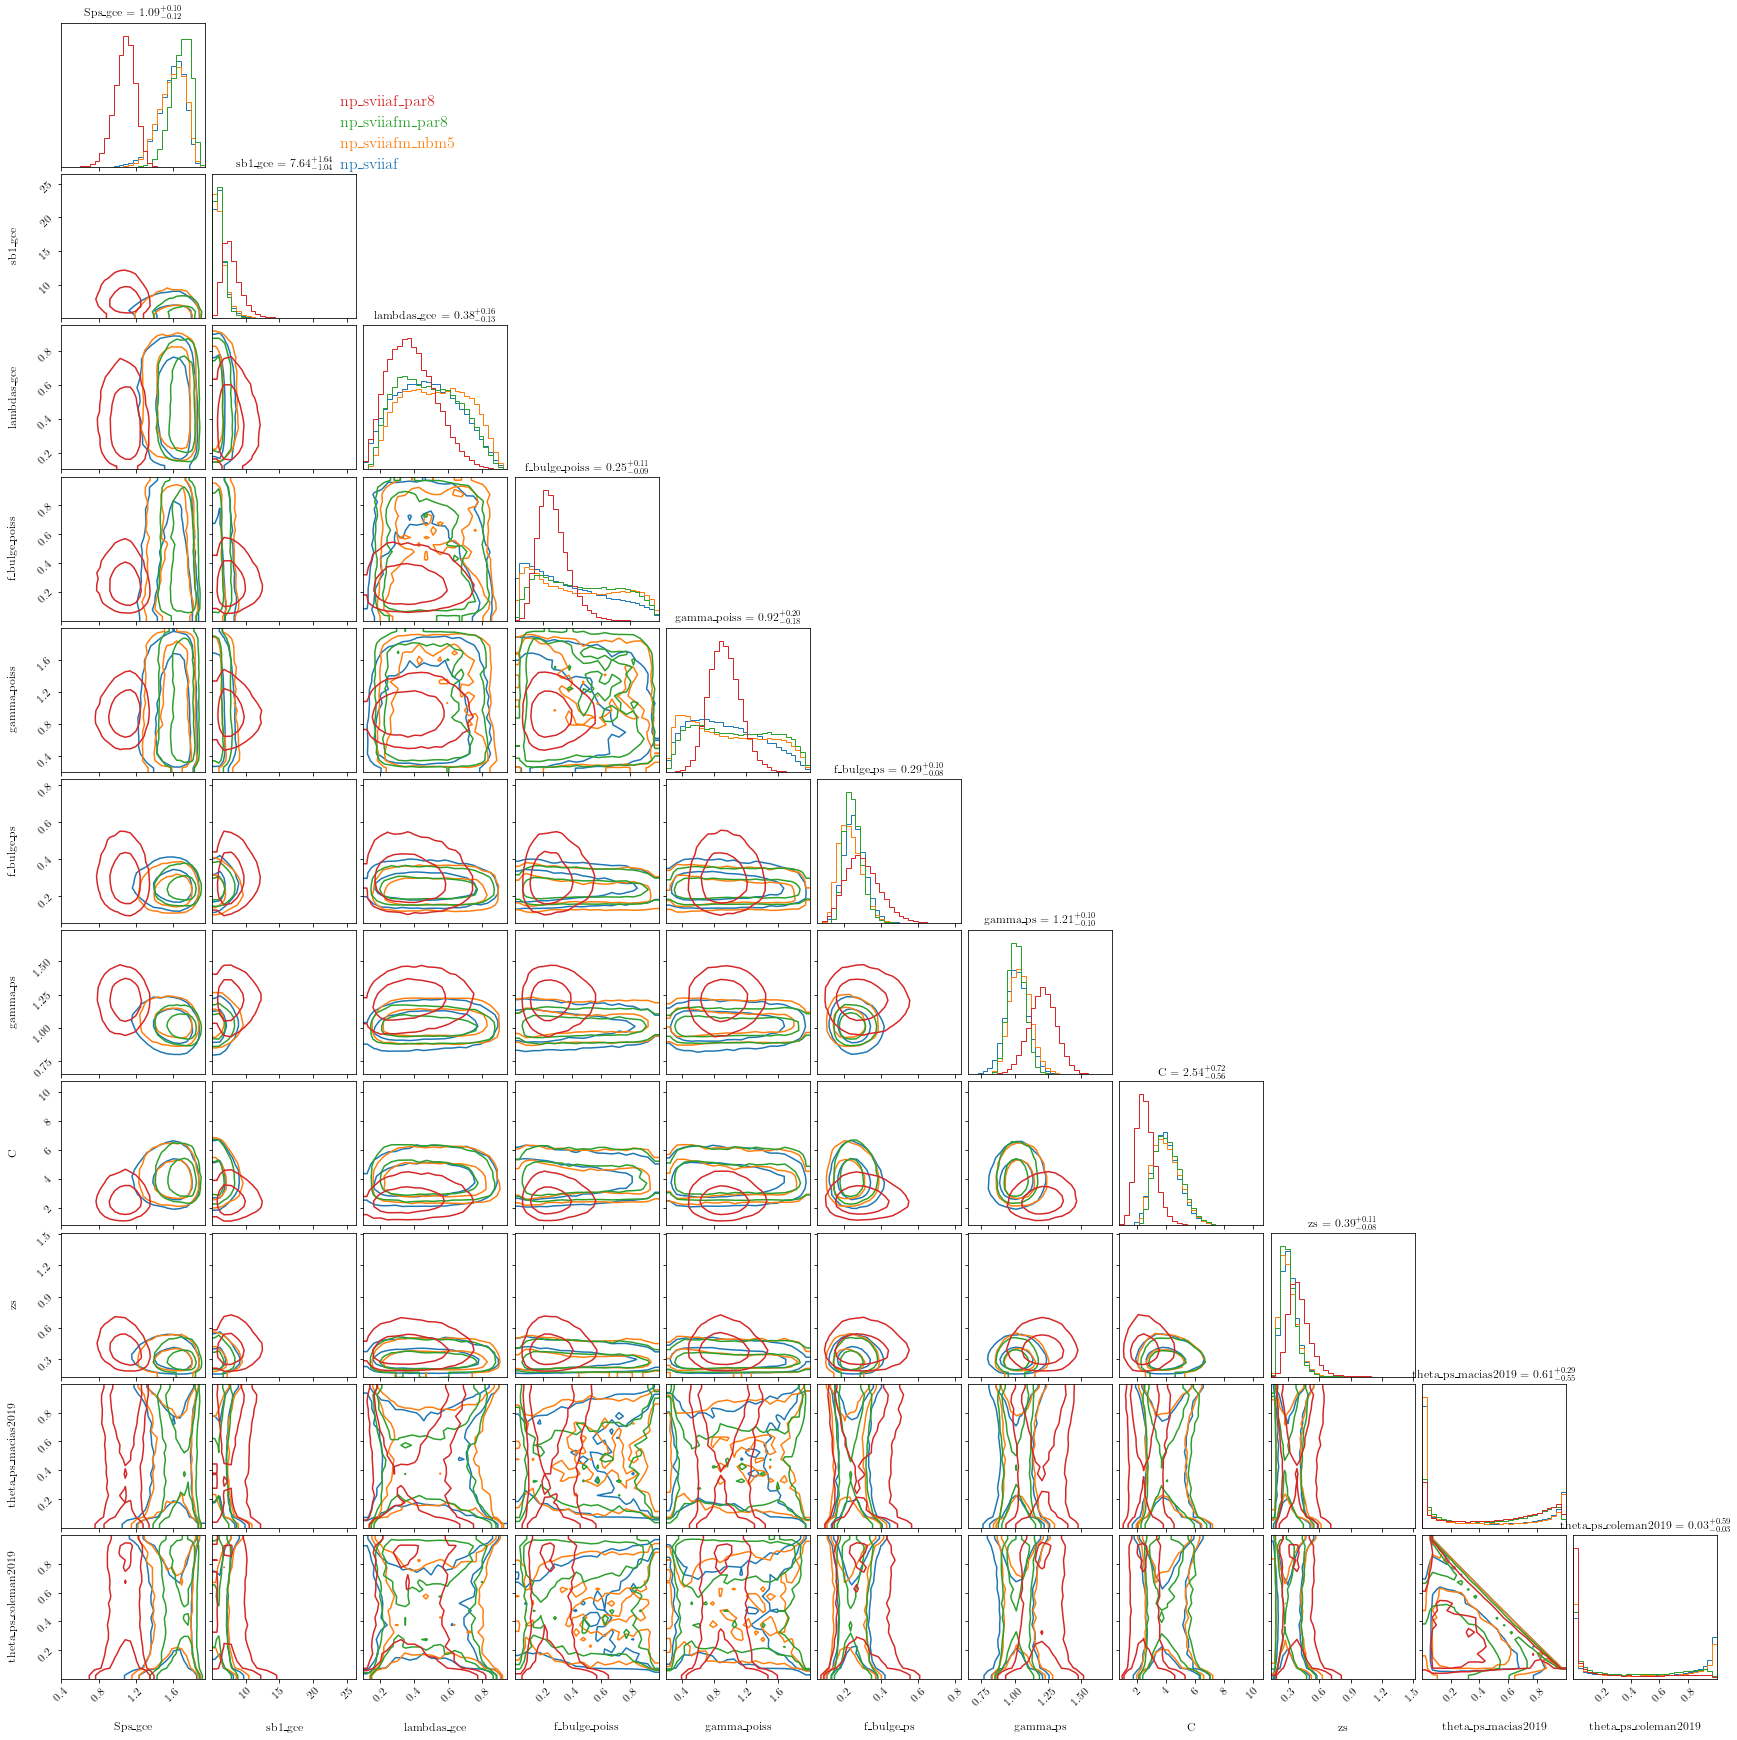

In [9]:
sn_s = ['np_sviiaf', 'np_sviiafm_nbm5', 'np_sviiafm_par8', 'np_sviiaf_par8']

samples = {}
for sn in sn_s:
    samples[sn] = expand_samples(
        pickle.load(open(f'../data/posteriors/{sn}_samples.p', 'rb')),
    )

plot_var_names = [
    #'S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso',
    'Sps_gce', 'sb1_gce', 'lambdas_gce',
    'f_bulge_poiss', 'gamma_poiss',
    'f_bulge_ps', 'gamma_ps',
    'C', 'zs',
    #'theta_ps_mcdermott2022', 'theta_ps_mcdermott2022_bbp', 'theta_ps_mcdermott2022_x',
    'theta_ps_macias2019', 'theta_ps_coleman2019',
]

n_bins_1d = 30
bins_1d_arr = []
for vn in plot_var_names:
    vmin = np.min([np.min(s[vn]) for _, s in samples.items()])
    vmax = np.max([np.max(s[vn]) for _, s in samples.items()])
    bins_1d_arr.append(np.linspace(vmin, vmax, n_bins_1d + 1))

figure = None
for i, sn in enumerate(sn_s):
    figure = corner.corner(
        samples[sn],
        bins_1d_arr=bins_1d_arr,
        var_names=plot_var_names,
        show_titles=True,
        title_kwargs={"fontsize": 12},
        levels = [0.68, 0.95],
        color = mpl.colors.to_hex(mpl.colors.to_rgb(f'C{i}') + (1.0,), keep_alpha=True),
        plot_contours=True,
        fill_contours=False,
        plot_density=False,
        plot_datapoints=False,
        fig=figure,
        alpha=1.0
    )
    figure.text(0.2, 0.9+0.012*i, sn, fontsize=16, color=f'C{i}', alpha=1.0)
#plt.savefig('compare.pdf')

### 2.2 NUTS

In [ ]:
npmodel.run_nuts(num_samples=5000)

In [ ]:
pickle.dump(npmodel.mcmc.get_samples(), open(f'{DATA_DIR}/np_nuts_samples.p', 'wb'))

### 2.3 Parallel tempering

In [10]:
npmodel.run_parallel_tempering_hmc(
    num_samples=20000,
    num_adaptation_steps=1000,
    step_size_base=3e-2,
)

sample: 100%|███████████████████████████████████████████████████████████████| 21000/21000 [1:11:14<00:00,  4.91it/s]


In [12]:
pickle.dump(npmodel.mcmc.get_samples(), open(f'../data/posteriors/np_pthmc_samples.p', 'wb'))

## 3. Compare

### 3.1 Different samplers

In [8]:
# poissonian
sn_s = ['sviiaf_par8', 'pthmc']
alphas = [1, 1]
# sn_s = ['svi_iaf', 'svi_iaf2', 'svi_iafmixture_C1', 'nuts', 'pthmc']
# alphas = [1, 1, 1, 0.2, 0.2]

samples = {sn : pickle.load(open(f'../data/posteriors/np_{sn}_samples.p', 'rb')) for sn in sn_s}
for sn, s in samples.items():
    if 'auto_shared_latent' in s:
        s.pop('auto_shared_latent')
        print(sn)
samples['pthmc'] = expand_samples(samples['pthmc'])

pthmc


In [ ]:
# non poissonian
sn_s = ['svi', 'sviiaf', 'pthmc']

samples = {}
for sn in sn_s:
    samples[sn] = expand_samples(
        pickle.load(open(f'{DATA_DIR}/np_{sn}_samples.p', 'rb')),
    )

In [12]:
samples['sviiaf_par8'].keys()

dict_keys(['Alm_0', 'Alm_1', 'Alm_2', 'Alm_3', 'Alm_4', 'Alm_5', 'C', 'S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso', 'S_psc', 'Sps_dsk', 'Sps_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'lambdas_dsk', 'lambdas_gce', 'n1_dsk', 'n1_gce', 'n2_dsk', 'n2_gce', 'n3_dsk', 'n3_gce', 'sb1_dsk', 'sb1_gce', 'theta_p_mcdermott2022', 'theta_p_mcdermott2022_bbp', 'theta_p_mcdermott2022_x', 'theta_p_macias2019', 'theta_p_coleman2019', 'theta_ps_mcdermott2022', 'theta_ps_mcdermott2022_bbp', 'theta_ps_mcdermott2022_x', 'theta_ps_macias2019', 'theta_ps_coleman2019', 'theta_MO_ics', 'theta_MA_ics', 'theta_MF_ics', 'theta_MO_pib', 'theta_MA_pib', 'theta_MF_pib', 'zs'])

In [13]:
samples['pthmc'].keys()

dict_keys(['Alm_0', 'Alm_1', 'Alm_2', 'Alm_3', 'Alm_4', 'Alm_5', 'C', 'S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso', 'S_psc', 'Sps_dsk', 'Sps_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'lambdas_dsk', 'lambdas_gce', 'n1_dsk', 'n1_gce', 'n2_dsk', 'n2_gce', 'n3_dsk', 'n3_gce', 'sb1_dsk', 'sb1_gce', 'theta_bulge_poiss', 'theta_bulge_ps', 'theta_ics', 'theta_pibrem', 'zs'])

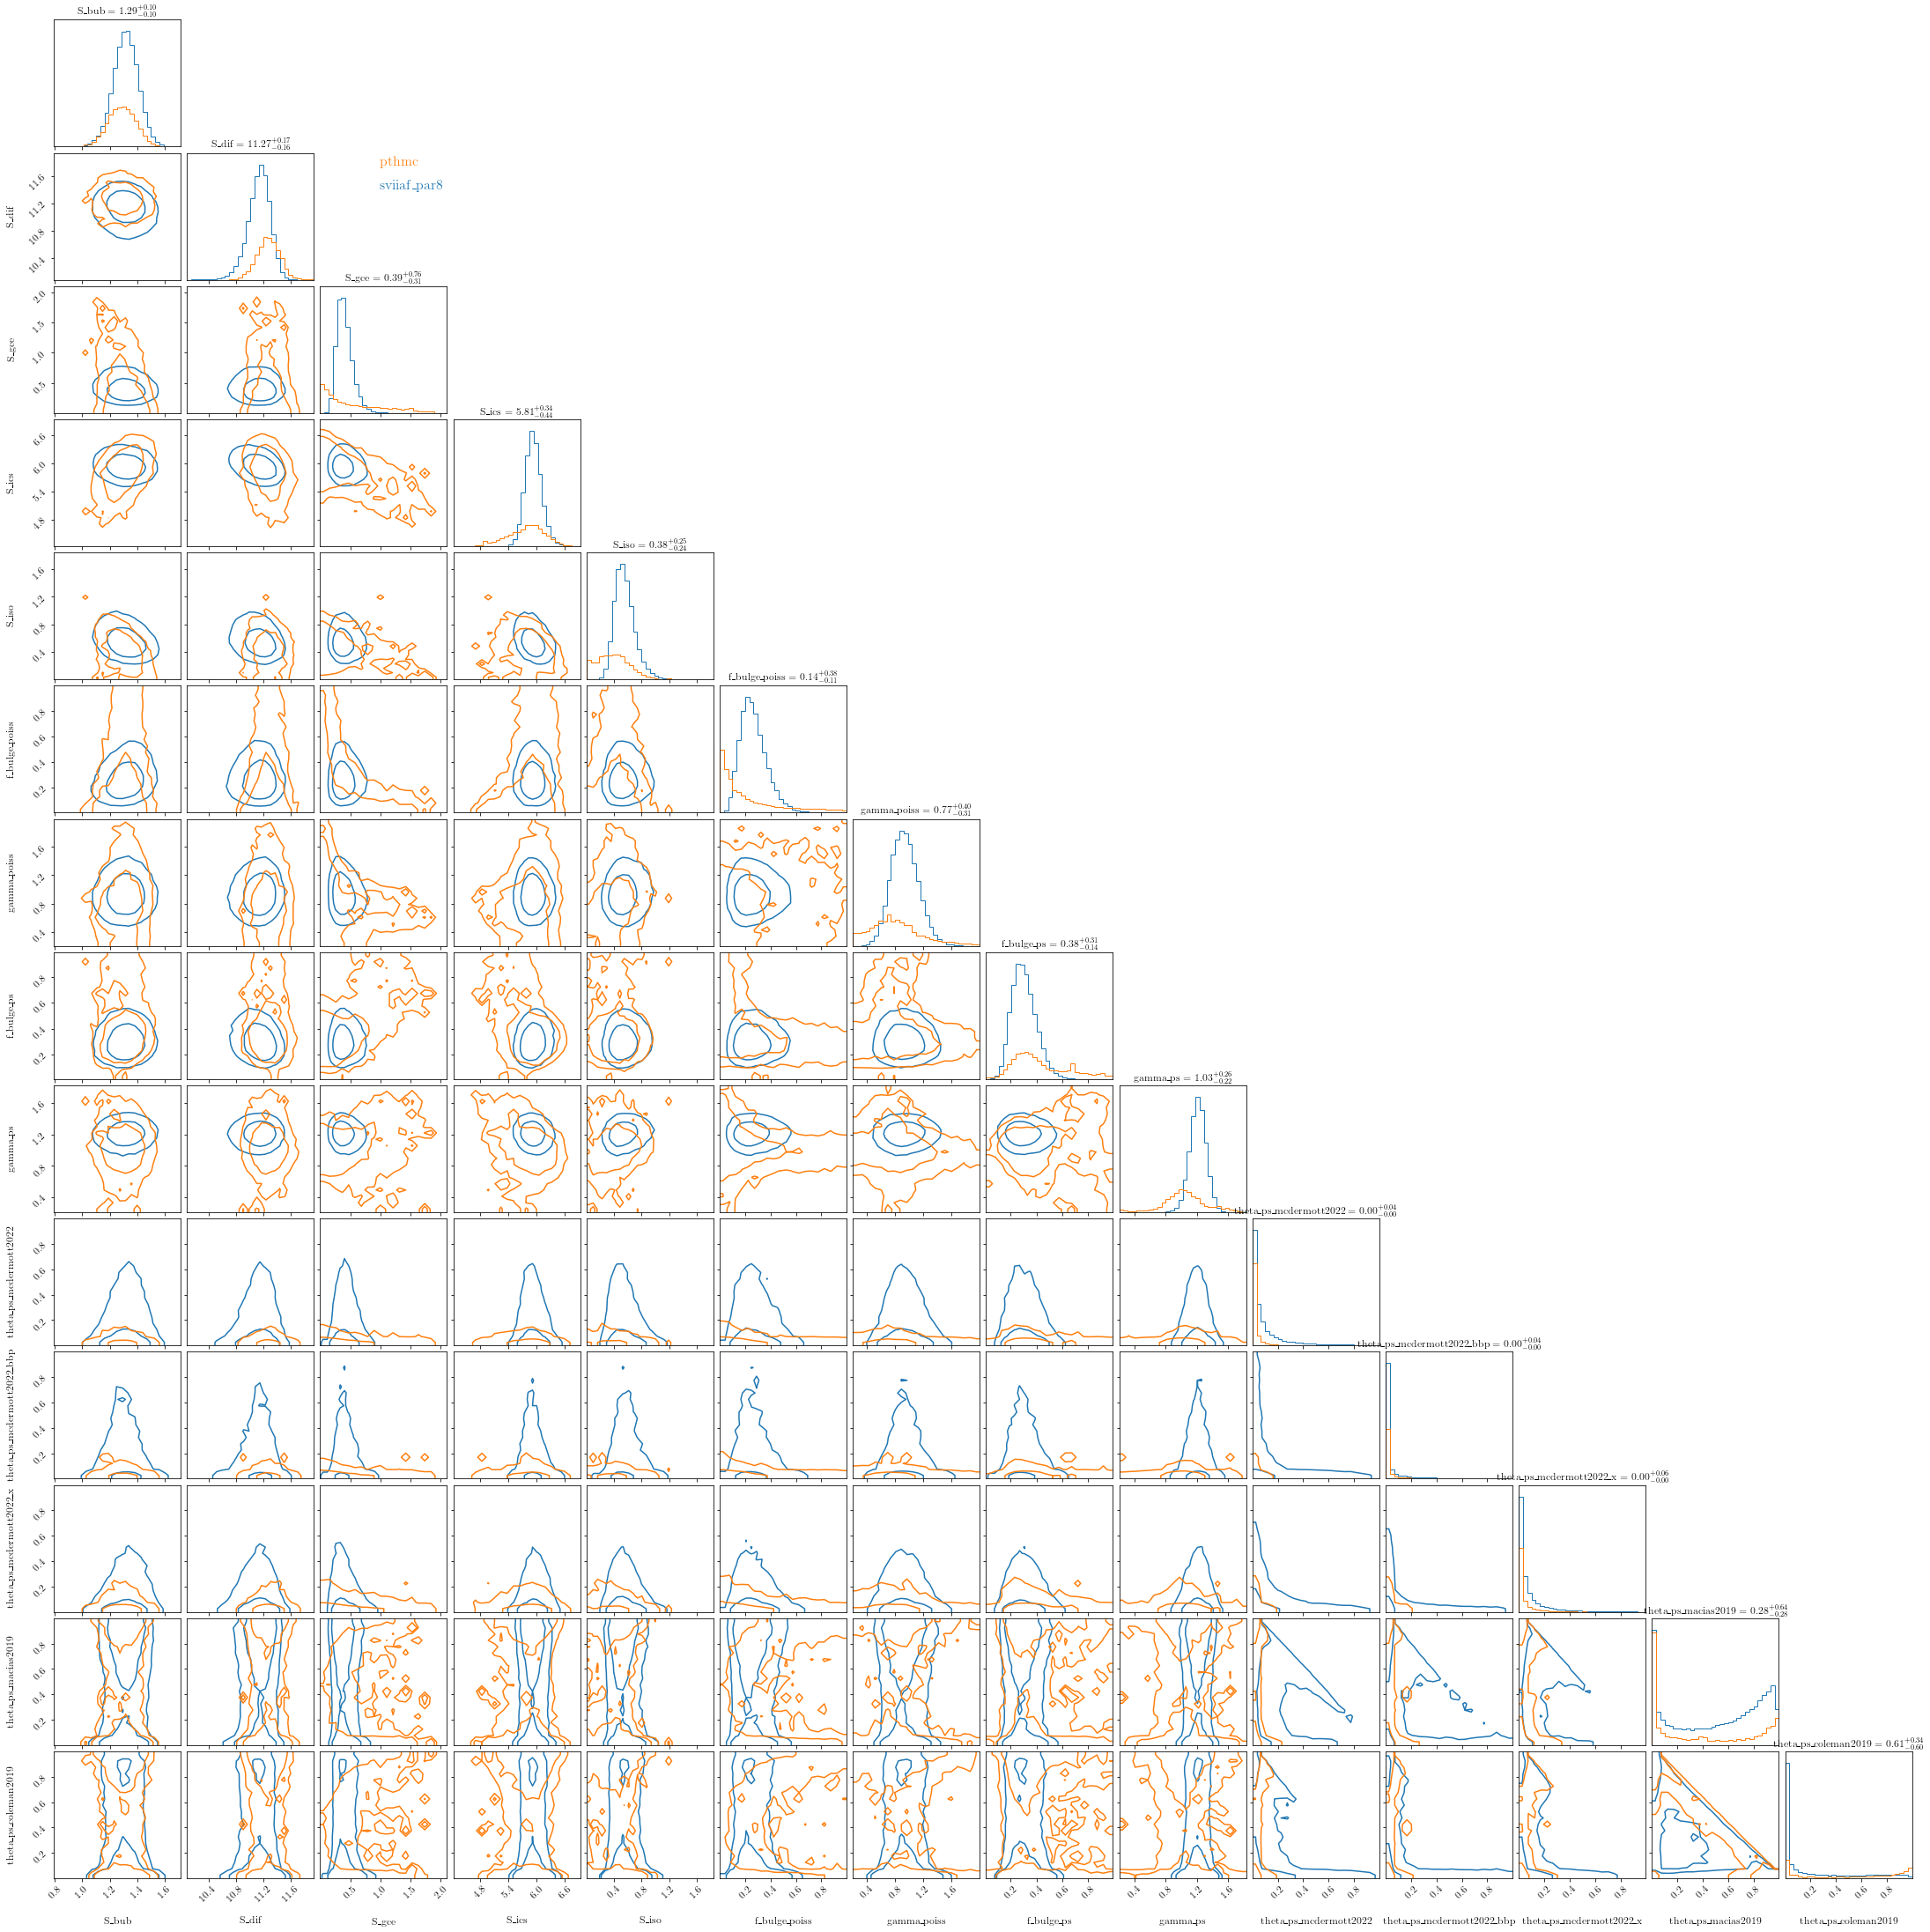

In [9]:
plot_var_names = [
    'S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso',
    'f_bulge_poiss', 'gamma_poiss',
    'f_bulge_ps', 'gamma_ps',
    'theta_ps_mcdermott2022', 'theta_ps_mcdermott2022_bbp', 'theta_ps_mcdermott2022_x', 'theta_ps_macias2019', 'theta_ps_coleman2019'
]

n_bins_1d = 30
bins_1d_arr = []
for vn in plot_var_names:
    vmin = np.min([np.min(s[vn]) for _, s in samples.items()])
    vmax = np.max([np.max(s[vn]) for _, s in samples.items()])
    bins_1d_arr.append(np.linspace(vmin, vmax, n_bins_1d + 1))

figure = None
for i, sn in enumerate(sn_s):
    figure = corner.corner(
        samples[sn],
        bins_1d_arr=bins_1d_arr,
        var_names=plot_var_names,
        show_titles=True,
        title_kwargs={"fontsize": 12},
        levels = [0.68, 0.95],
        color = mpl.colors.to_hex(mpl.colors.to_rgb(f'C{i}') + (alphas[i],), keep_alpha=True),
        plot_contours=True,
        fill_contours=False,
        plot_density=False,
        plot_datapoints=False,
        fig=figure,
        alpha=alphas[i]
    )
    figure.text(0.2, 0.9+0.012*i, sn, fontsize=16, color=f'C{i}', alpha=alphas[i])
plt.savefig('compare.pdf')

### 3.2 RNG

In [44]:
# poissonian
sn_s = [f'{i}' for i in range(3)]
alphas = np.ones_like(sn_s, dtype=float)

samples = {sn : pickle.load(open(f'{DATA_DIR}/rng/{sn}.p', 'rb')) for sn in sn_s}
for sn, s in samples.items():
    if 'auto_shared_latent' in s:
        s.pop('auto_shared_latent')
        print(sn)

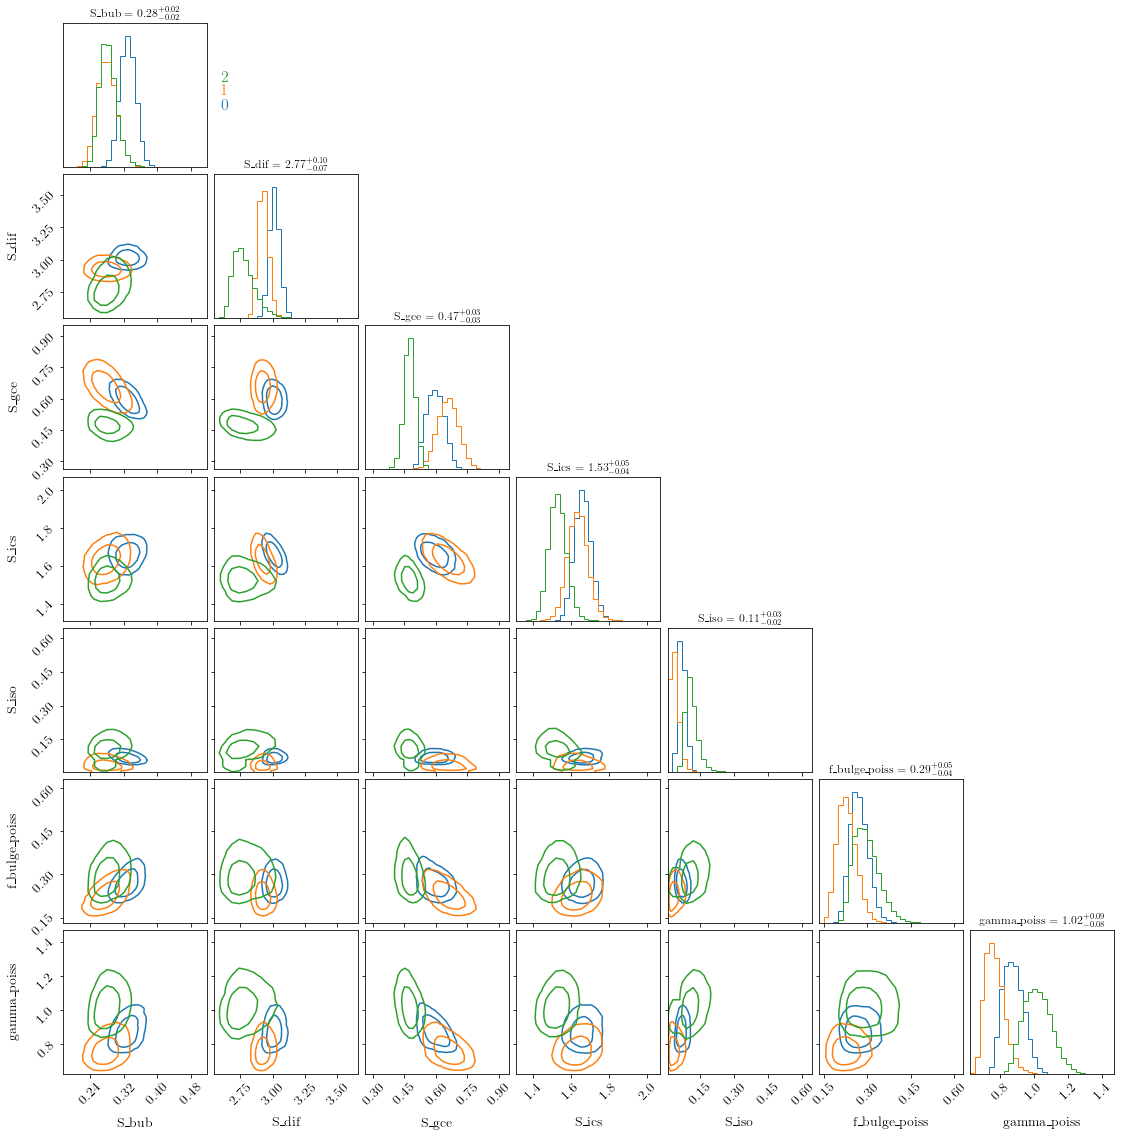

In [45]:
plot_var_names = [
    'S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso',
    'f_bulge_poiss', 'gamma_poiss',
    #'f_bulge_ps', 'gamma_ps',
    #'theta_ps_mcdermott2022', 'theta_ps_mcdermott2022_bbp', 'theta_ps_mcdermott2022_x', 'theta_ps_macias2019', 'theta_ps_coleman2019'
]

n_bins_1d = 30
bins_1d_arr = []
for vn in plot_var_names:
    vmin = np.min([np.min(s[vn]) for _, s in samples.items()])
    vmax = np.max([np.max(s[vn]) for _, s in samples.items()])
    bins_1d_arr.append(np.linspace(vmin, vmax, n_bins_1d + 1))

figure = None
for i, sn in enumerate(sn_s):
    figure = corner.corner(
        samples[sn],
        bins_1d_arr=bins_1d_arr,
        var_names=plot_var_names,
        show_titles=True,
        title_kwargs={"fontsize": 12},
        levels = [0.68, 0.95],
        color = mpl.colors.to_hex(mpl.colors.to_rgb(f'C{i}') + (alphas[i],), keep_alpha=True),
        plot_contours=True,
        fill_contours=False,
        plot_density=False,
        plot_datapoints=False,
        fig=figure,
        alpha=alphas[i]
    )
    figure.text(0.2, 0.9+0.012*i, sn, fontsize=16, color=f'C{i}', alpha=alphas[i])
plt.savefig('rng_var.pdf')